<a href="https://colab.research.google.com/github/Bastrikoff/statprak/blob/main/3_random.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/drive/1_7ZERbrfywPfYD4pPOh6PNoDqQ-0Yq8D?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem 1
Implement serial test and apply to a `samples`

In [ ]:
import numpy as np
from scipy import stats

try:
    samples
except NameError:
    np.random.seed(42)
    samples = np.random.rand(1000)

def serial_test(data, bins=10):

    n_pairs = len(data) // 2
    pairs = np.array([data[0::2], data[1::2]]).T
    H, _, _ = np.histogram2d(pairs[:,0], pairs[:,1],
                             bins=bins, range=[[0,1],[0,1]])
    observed = H.flatten()
    expected = np.full(bins * bins, n_pairs / (bins * bins))
    chi2, p = stats.chisquare(observed, expected)
    return chi2, p

chi2_serial, p_serial = serial_test(samples)
print(f"Serial test: χ² = {chi2_serial:.4f}, p-value = {p_serial:.4f}")
if p_serial > 0.05:
    print("Нет оснований отвергать гипотезу о случайности.")
else:
    print("Обнаружена зависимость между соседними значениями.")

Serial test: χ² = 98.4000, p-value = 0.4981
Нет оснований отвергать гипотезу о случайности.


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
import numpy as np
from scipy import stats

def rng_good(m=2**32, a=1103515245, c=12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

rng_good.current = 1
rng_bad.current = 1

samples_good = [rng_good() for _ in range(1000)]
samples_bad = [rng_bad() for _ in range(1000)]

def serial_test(data, bins=10):
    n_pairs = len(data) // 2
    pairs = np.array([data[0::2], data[1::2]]).T
    H, _, _ = np.histogram2d(pairs[:,0], pairs[:,1], bins=bins, range=[[0,1],[0,1]])
    observed = H.flatten()
    expected = np.full(bins*bins, n_pairs / (bins*bins))
    chi2, p = stats.chisquare(observed, expected)
    return chi2, p

chi2_good, p_good = serial_test(samples_good)
chi2_bad, p_bad = serial_test(samples_bad)

print("Хороший генератор (rng_good):")
print(f"  χ² = {chi2_good:.4f}, p-value = {p_good:.4f}")
print("Плохой генератор (rng_bad):")
print(f"  χ² = {chi2_bad:.4f}, p-value = {p_bad:.4f}")

if p_good > 0.05 and p_bad < 0.05:
    print("Тест показывает, что rng_bad имеет проблемы (p < 0.05), а rng_good — нет.")
else:
    print("Результаты неоднозначны, возможно, нужно увеличить выборку или использовать другой тест.")

Хороший генератор (rng_good):
  χ² = 114.4000, p-value = 0.1380
Плохой генератор (rng_bad):
  χ² = 127.6000, p-value = 0.0280
Тест показывает, что rng_bad имеет проблемы (p < 0.05), а rng_good — нет.


* More randomness tests - [Diehard tests](https://en.wikipedia.org/wiki/Diehard_tests).
* More methods for generating a uniform value [here](https://en.wikipedia.org/wiki/List_of_random_number_generators).
* A story about dynamical systems and the transition to chaos https://www.youtube.com/watch?v=ovJcsL7vyrk&feature=youtu.be

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

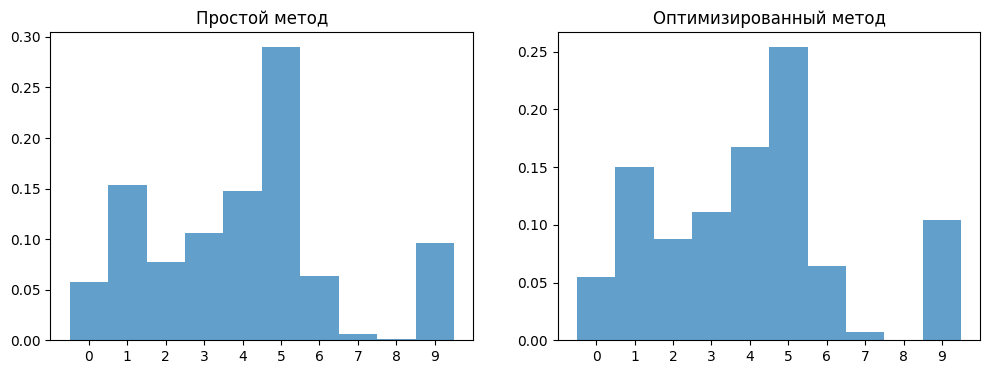

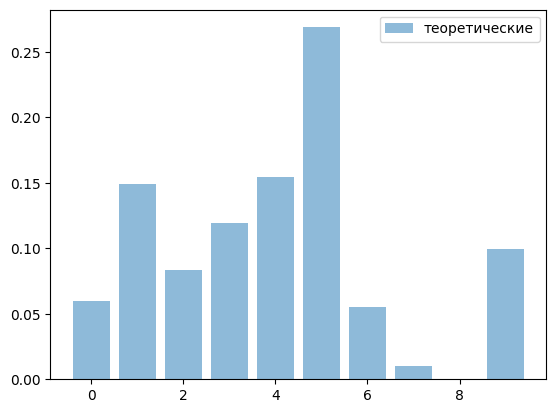

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
weights = weights / weights.sum()
digits = np.arange(10)

sample_simple = np.random.choice(digits, size=1000, p=weights)

sorted_indices = np.argsort(weights)[::-1]
sorted_weights = weights[sorted_indices]
cumsum = np.cumsum(sorted_weights)

u = np.random.rand(1000)
sample_opt = np.zeros(1000, dtype=int)
for i in range(1000):
    idx = np.searchsorted(cumsum, u[i])
    sample_opt[i] = sorted_indices[idx]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(sample_simple, bins=np.arange(11)-0.5, density=True, alpha=0.7, label='простой')
plt.xticks(digits)
plt.title('Простой метод')
plt.subplot(1,2,2)
plt.hist(sample_opt, bins=np.arange(11)-0.5, density=True, alpha=0.7, label='оптимизированный')
plt.xticks(digits)
plt.title('Оптимизированный метод')
plt.show()

plt.bar(digits, weights, alpha=0.5, label='теоретические')
plt.legend()
plt.show()

# Generating a sample from a given distribution

Suppose we have a random number generator from the segment [0, 1] (use the `np.random.rand()` function for this). How to get a sample from another distribution $F$?

## Inverse transform method

The following proposition is the idea behind the *inverse transform* method:

If $\xi$ has a uniform distribution in $[0,1]$, then $F^{-1}(\xi)$ is distributed according to the law of $F$. (For which $F$ is this true?)

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

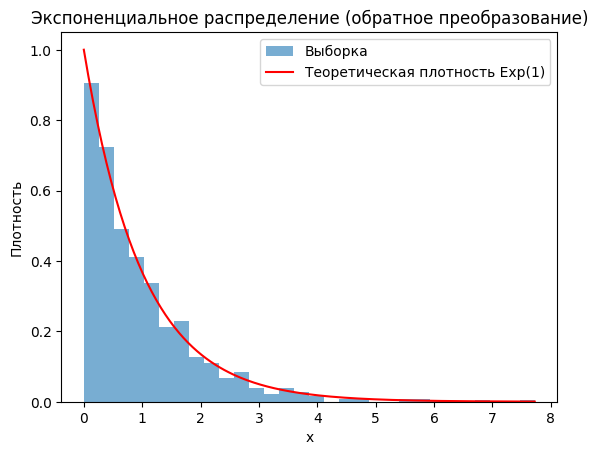

In [ ]:
lam = 1.0
n = 1000
u = np.random.rand(n)
x = -np.log(1 - u) / lam

plt.hist(x, bins=30, density=True, alpha=0.6, label='Выборка')
t = np.linspace(0, max(x), 200)
plt.plot(t, lam * np.exp(-lam * t), 'r-', label='Теоретическая плотность Exp(1)')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Экспоненциальное распределение (обратное преобразование)')
plt.legend()
plt.show()

## Rejection sampling (Accept-reject method)

The idea of the method is to sample from the distribution we know how to sample from, and then select points that follow the desired distribution. More precisely: let's say we know how to sample from a distribution with density $p$, and we want to sample from a distribution with density $\pi$. Let's take a random $x$ from the distribution $p$. Then take $y$ uniformly distributed on the interval $[0, p(x)]$. If the point $(x, y)$ falls under the graph of $\pi$, we take $x$ as a sampling element from $\pi$. If not, we repeat the procedure for a new $x$. The picture illustrates the idea of the method (the densities are normalised so that one lies entirely under the other):

<img src=https://colcarroll.github.io/hamiltonian_monte_carlo_talk/images/bayes_talk.015.png style="width: 50%;"/>

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

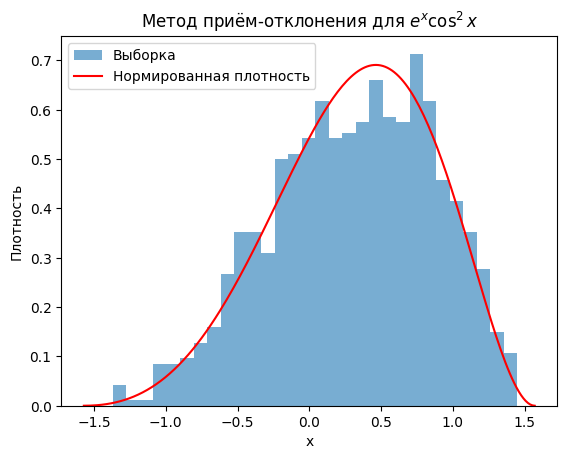

In [ ]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

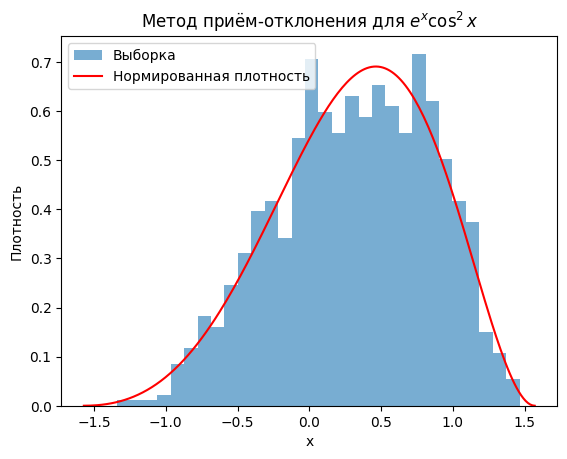

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def target(x):
    return np.exp(x) * np.cos(x)**2

a, b = -np.pi/2, np.pi/2
M = 1.0

n = 1000
samples = []
while len(samples) < n:
    x = np.random.uniform(a, b)
    y = np.random.uniform(0, M)
    if y <= target(x):
        samples.append(x)

plt.hist(samples, bins=30, density=True, alpha=0.6, label='Выборка')
x_plot = np.linspace(a, b, 200)

norm_const, _ = quad(target, a, b)
plt.plot(x_plot, target(x_plot) / norm_const, 'r-', label='Нормированная плотность')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(r'Метод приём-отклонения для $e^x \cos^2 x$')
plt.legend()
plt.show()

## Coordinate transformation method

The accept-reject method may in some cases be inefficient and require too many sample points. An alternative is to try to find a coordinate transformation that converts a simple area (from which it is easy to sample, for example, a unit square) into the required area, but preserves the area ratio (why?).

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

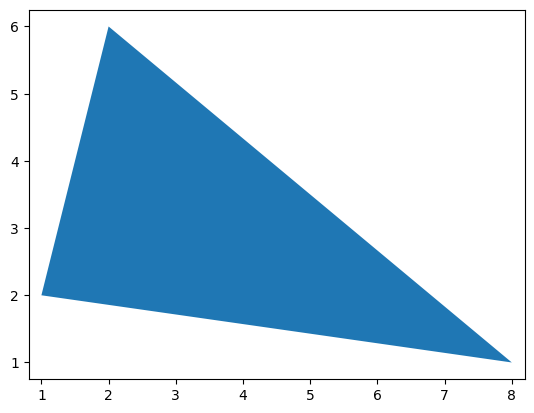

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

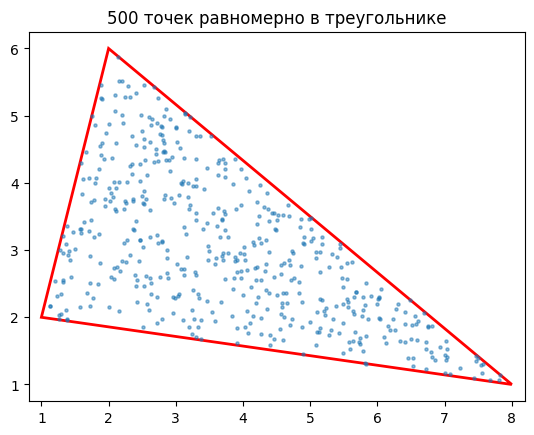

In [ ]:
A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n = 500

u = np.random.rand(n)
v = np.random.rand(n)
mask = u + v > 1
u[mask] = 1 - u[mask]
v[mask] = 1 - v[mask]

points = (1 - u - v)[:, None] * A + u[:, None] * B + v[:, None] * C

plt.figure()
polygon = plt.Polygon([A, B, C], closed=True, fill=None, edgecolor='red', linewidth=2)
plt.gca().add_patch(polygon)
plt.scatter(points[:,0], points[:,1], s=5, alpha=0.5)
plt.axis('equal')
plt.title('500 точек равномерно в треугольнике')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

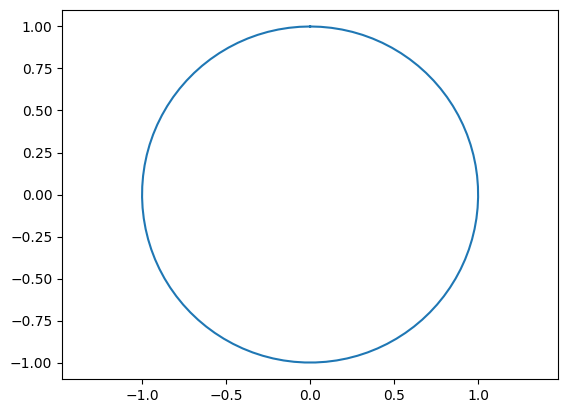

In [ ]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

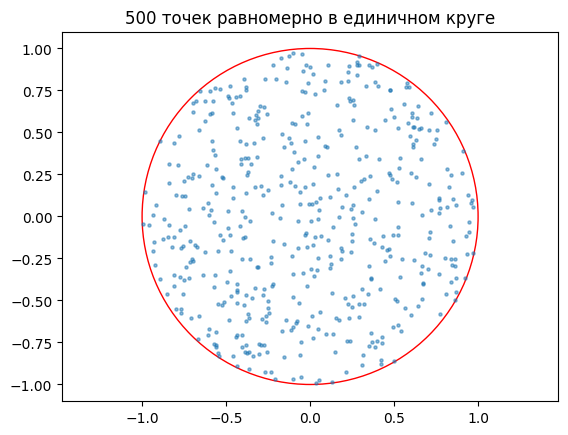

In [ ]:
n = 500

u = np.random.rand(n)
theta = 2 * np.pi * np.random.rand(n)
r = np.sqrt(u)
x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure()
circle = plt.Circle((0,0), 1, fill=None, edgecolor='red')
plt.gca().add_patch(circle)
plt.scatter(x, y, s=5, alpha=0.5)
plt.axis('equal')
plt.title('500 точек равномерно в единичном круге')
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [ ]:
import seaborn as sns

Выборочное среднее:
 [3.77276993 6.77707174]
Выборочная ковариация:
 [[19.92379973 -3.6520406 ]
 [-3.6520406  36.48567016]]


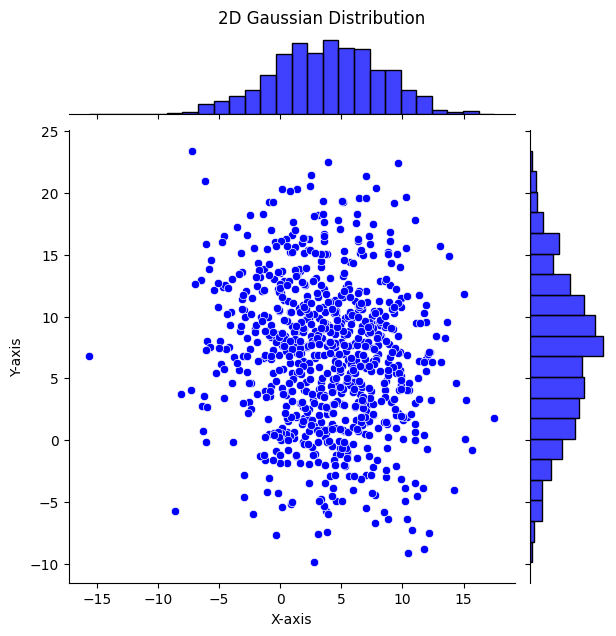

In [ ]:
n = 1000

u1 = np.random.uniform(-1, 1, n)
u2 = np.random.uniform(-1, 1, n)
S = (u1**2 + u2**2)
mask = (S < 1) & (S > 0)
v1 = u1[mask]
v2 = u2[mask]
S_masked = S[mask]



r = np.sqrt(-2 * np.log(S_masked))
cosine = v1 / np.sqrt(S_masked)
sine = v2 / np.sqrt(S_masked)

x = r * cosine
y = r * sine

Z = np.vstack([x, y])
mu = np.array([[4], [7]])
sigma = np.array([[20, -4],
                 [-4, 40]])
L = np.linalg.cholesky(sigma)


Z_final = mu + L @ Z

x_res = Z_final[0, :]
y_res = Z_final[1, :]

print("Выборочное среднее:\n", np.mean(Z_final, axis=1))
print("Выборочная ковариация:\n", np.cov(Z_final))

joint_plot = sns.jointplot(x=x_res, y=y_res, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()